Place for examples of capabilities. The following cell is the most reliable way I've found to accomplish the desired behavior, but it might be overkill.

In [1]:
using Pkg
Pkg.activate("..")
Pkg.resolve()
Pkg.instantiate()
Pkg.precompile()

  Activating project at `c:\Users\camde\.julia\dev\HybridDynamics.jl`
     Project No packages added to or removed from `C:\Users\camde\.julia\dev\HybridDynamics.jl\Project.toml`
    Manifest No packages added to or removed from `C:\Users\camde\.julia\dev\HybridDynamics.jl\Manifest.toml`
Precompiling packages...
    497.8 ms  ? HybridDynamics
Precompiling packages...
    422.3 ms  ? HybridDynamics


In [2]:
import HybridDynamics as HD


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.


In [3]:
import Plots as plt
import LaTeXStrings as latstr

In [12]:
init = [1.,0.];
tspan = (0., 5.);

function M(q)
    [1.0;;]
end

function V(q)
    q[1]^2
end

# Table/guard
g(q) = q[1]

Lsys = HD.LagSys(M, V; guard = g, e=1.0)

probl = HD.prob(Lsys, init, tspan)
sl = HD.solve(probl, solver = HD.RK4())


HybridDynamics.LHSol{Vector{Float64}, Vector{Vector{Float64}}, Vector{Vector{Float64}}, HybridDynamics.prob{HybridDynamics.LagSys{typeof(M), typeof(V), typeof(g), HybridDynamics.var"#13#14"{typeof(g)}, HybridDynamics.var"#LagSys##2#LagSys##3", Float64}, Vector{Float64}, Tuple{Float64, Float64}}, Vector{Float64}, Vector{Int64}, Vector{Float64}, Vector{Float64}}([0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.060000000000000005, 0.11000000000000001, 0.2, 0.37, 0.7, 1.111192251093523, 1.111192251093523, 2.112384502187046, 2.942154417372529, 2.942154417372529, 4.32720356903207, 4.32720356903207, 5.0], [[1.0, 0.0], [0.9999000016666667, -0.019999333333333338], [0.9996000266661111, -0.03999466686666445], [0.9991001349923335, -0.05998200159994001], [0.9984004266220023, -0.07995734013284003], [0.9975010414944592, -0.09991668746424462], [0.9964021594837315, -0.11985605179122086], [0.9879243834165352, -0.2191137189468796], [0.9602660087924788, -0.39468755159656244], [0.8661974746428258, -0.7066812742423945

In [13]:
print(sl.t)

[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.060000000000000005, 0.11000000000000001, 0.2, 0.37, 0.7, 1.111192251093523, 1.111192251093523, 2.112384502187046, 2.942154417372529, 2.942154417372529, 4.32720356903207, 4.32720356903207, 5.0]

How tf am I going backwards in time...

In [14]:
print(sl.jump_times)

[1.111192251093523, 2.942154417372529, 4.32720356903207]

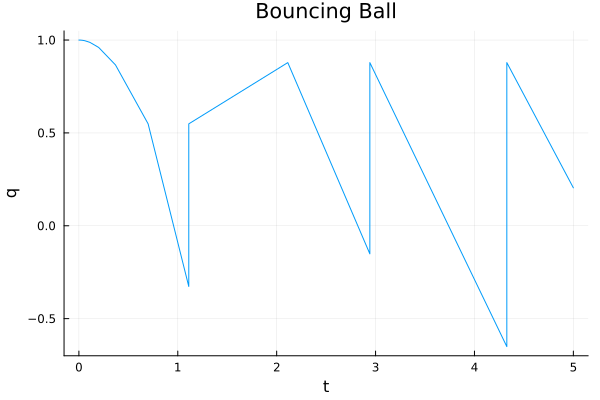

In [15]:
q_vals = getindex.(sl.x, 1)

pl2 = plt.plot(sl.t, q_vals,
    title = "Bouncing Ball",
    xlabel = "t",
    ylabel = "q",
    label = ""
)

display(pl2)

In [8]:
# Attempt a Filippov system
F(x) = [1, -1]
G(x) = [0, 1]
H(x) = x[2]-sin(x[1])
N(x) = [-cos(x[1]), 1]

Fsys = HD.FilippovSys(F, G, H, N)
probF = HD.prob(Fsys, [0.0, 1.0], (0.0, 5.0))
solF = HD.solve(probF, HD.RK4(); dt_initial=0.01)

MethodError: MethodError: no method matching (::HybridDynamics.var"#vf#46"{HybridDynamics.FilippovSys{typeof(F), typeof(G), typeof(H), typeof(N)}})(::Vector{Float64}, ::Float64)
The function `vf` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  (::HybridDynamics.var"#vf#46")(::Any)
   @ HybridDynamics c:\Users\camde\.julia\dev\HybridDynamics.jl\src\Systems\Filippov.jl:130
